# Mental Health and Academic Performance Predictor

This notebook analyzes how college students' mental health, discipline, sleep, and screen-time habits relate to GPA. It walks through:

1. **Data loading & cleaning** (`DataPipeline`)
2. **Dataset summary** (`data_summary`)
3. **Exploratory Data Analysis** (`data_eda`)
4. **Model training & evaluation** (`ModelTrainer`)
5. **Interactive GPA prediction**

> **Setup:** Download the dataset from Kaggle, rename the CSV to `students.csv`, and place it in the `data/` folder before running.
>
> Dataset URL: https://www.kaggle.com/datasets/sharmajicoder/college-students-habits-and-performance

## 0. Imports & Setup

In [1]:
# Standard library
import math
import itertools
from functools import reduce

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project modules
from data_pipeline import DataPipeline, FEATURE_COLUMNS, TARGET_COLUMN
from data_summary import print_data_summary
from data_eda import run_eda
from model_trainer import ModelTrainer
from utils import find_missing_columns

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
print("All modules imported successfully.")

All modules imported successfully.


## 1. Load & Clean the Data

In [2]:
# Instantiate the pipeline - one of the two required classes.
# DataPipeline composes with ModelTrainer (composition relationship).
pipeline = DataPipeline(csv_path="data/students.csv")

# Exception-handling scenario 1: missing CSV file
try:
    df = pipeline.clean()
except FileNotFoundError as e:
    print(f"[ERROR] {e}")
    raise

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns after cleaning.")
df.head(3)

Loaded 998,442 rows x 42 columns after cleaning.


,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,hostel_student,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress,gpa,performance_level
0,3.014684,67.00599,51.595387,57.211285,61.653540,65.397200,4,5.993893,4.287966,58.14600,...,0,1.958940,73.727480,5.721128,3.587111,2.814086,1.814086,5.491878,0.546729,Low
1,3.665277,73.28455,69.749020,57.552320,62.062782,65.715500,3,6.949383,1.841224,41.94529,...,0,3.146447,48.468456,5.755232,4.820090,2.836821,1.836821,2.876881,0.707133,Low
2,2.703784,72.32519,92.837640,44.568970,46.482760,53.597702,2,6.703293,3.863112,56.55575,...,1,5.551245,46.623684,4.456897,5.493774,1.971265,0.971265,5.704047,0.868230,Low


## 2. Dataset Summary

In [3]:
print_data_summary()

Student Data Summary
--------------------
Rows: 998442
Columns: 42

Column names:
study_hours
attendance
assignment_completion
midterm_score
final_score
project_score
backlogs
sleep_hours
stress
anxiety
depression
motivation
concentration
time_management
self_discipline
social_media_hours
gaming_hours
netflix_hours
screen_time
physical_activity
junk_food_frequency
caffeine_mg
late_night_frequency
procrastination_score
family_income
parental_education_level
internet_quality
library_visits
online_courses_completed
part_time_hours
peer_study_group
relationship_status
hostel_student
extracurricular_hours
phone_unlocks_per_day
previous_gpa
class_participation
weekly_study_sessions
group_study_hours
financial_stress
gpa
performance_level

Missing values:
study_hours                 0
attendance                  0
assignment_completion       0
midterm_score               0
final_score                 0
project_score               0
backlogs                    0
sleep_hours                 0
s

## 3. Feature & Target Split

In [4]:
# Exception-handling scenario 2: schema mismatch (missing required columns)
try:
    X, y = pipeline.get_features_and_target()
except ValueError as e:
    print(f"[ERROR] {e}")
    raise

print(f"Features : {X.shape[1]} columns")
print(f"Target   : '{y.name}' - range [{y.min():.3f}, {y.max():.3f}]")

Features : 13 columns
Target   : 'gpa' - range [0.000, 2.009]


## 4. Exploratory Data Analysis

Correlation with GPA (strongest first):

  previous_gpa                        +0.780
  concentration                       +0.715
  motivation                          +0.640
  time_management                     +0.622
  self_discipline                     +0.622
  procrastination_score               -0.571
  sleep_hours                         +0.385
  phone_unlocks_per_day               -0.334
  late_night_frequency                -0.333
  financial_stress                    -0.158
  stress                              -0.047
  depression                          -0.002
  anxiety                             -0.002


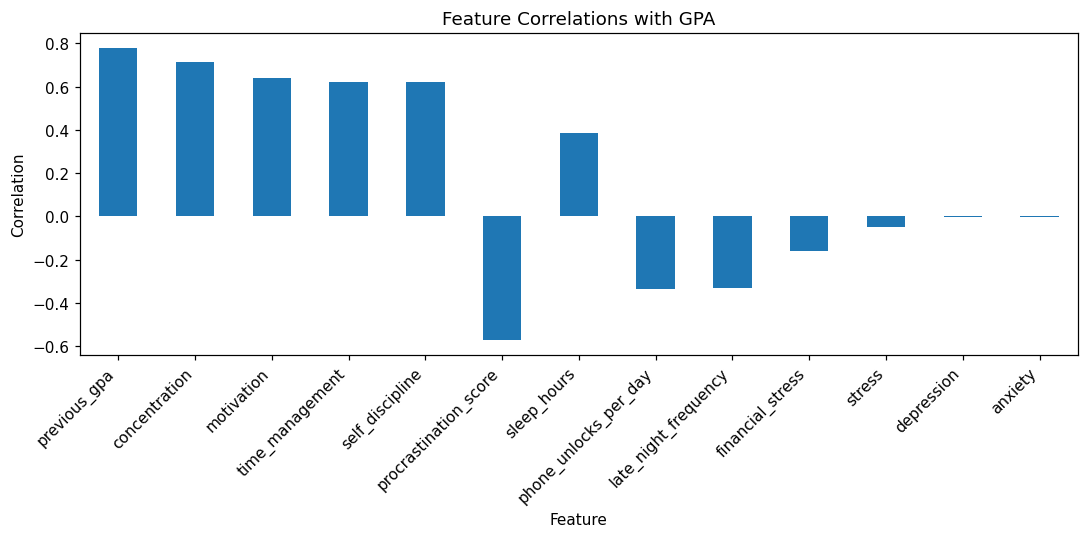

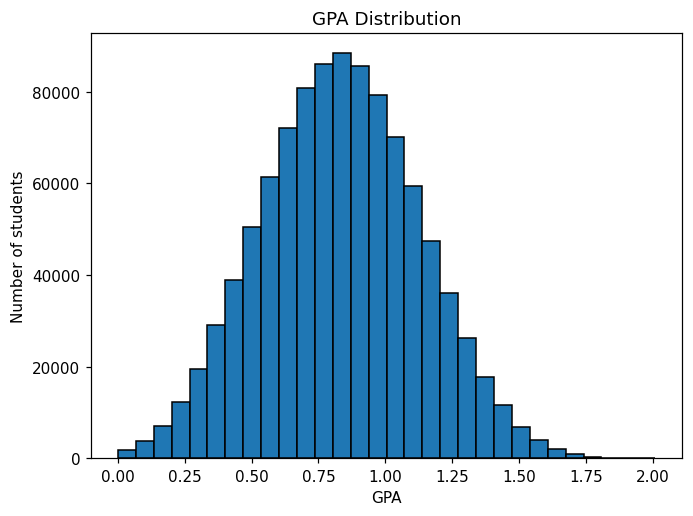

In [5]:
# Calls run_eda() from data_eda.py - prints correlations and shows both charts
run_eda(X, y)

In [6]:
# List comprehension (Part 2 requirement)
df_num = pd.concat([X, y], axis=1).select_dtypes(include="number")
correlations = df_num.corr()["gpa"].drop("gpa").sort_values(key=abs, ascending=False)

strong_predictors = [feat for feat, r in correlations.items() if abs(r) > 0.3]
print("Features with |r| > 0.3:", strong_predictors)

Features with |r| > 0.3: ['previous_gpa', 'concentration', 'motivation', 'time_management', 'self_discipline', 'procrastination_score', 'sleep_hours', 'phone_unlocks_per_day', 'late_night_frequency']


In [7]:
# Generator function (Part 2 requirement)
def feature_stats_generator(dataframe):
    """Yield (feature_name, mean, std) tuples one at a time."""
    for col in dataframe.columns:
        yield col, dataframe[col].mean(), dataframe[col].std()

print(f"{'Feature':<35} {'Mean':>8} {'Std':>8}")
print("-" * 55)
for name, mean, std in feature_stats_generator(X):
    print(f"{name:<35} {mean:>8.3f} {std:>8.3f}")

Feature                                 Mean      Std
-------------------------------------------------------
stress                                 3.209    1.755
anxiety                               49.966   14.993
depression                            44.971   14.984
motivation                             6.005    0.971
concentration                          6.007    1.092
time_management                        6.004    0.997
self_discipline                        6.004    0.997
procrastination_score                  5.000    1.655
financial_stress                       4.996    1.339
sleep_hours                            6.501    0.435
late_night_frequency                   2.008    0.979
phone_unlocks_per_day                 60.039   19.869
previous_gpa                           6.005    1.493


In [8]:
# Set operations (Part 2 requirement)
# Mutable type: set. Immutable types: strings inside the set.
all_features: set = set(X.columns)
high_correlation_features: set = set(strong_predictors)
low_correlation_features = all_features - high_correlation_features

print("Total features    :", len(all_features))
print("High |r| (> 0.3)  :", high_correlation_features)
print("Low  |r| (<= 0.3) :", low_correlation_features)

Total features    : 13
High |r| (> 0.3)  : {'previous_gpa', 'sleep_hours', 'time_management', 'motivation', 'phone_unlocks_per_day', 'concentration', 'late_night_frequency', 'procrastination_score', 'self_discipline'}
Low  |r| (<= 0.3) : {'financial_stress', 'stress', 'anxiety', 'depression'}


In [9]:
# reduce() and lambda (Part 2 requirement)
# Cumulative sum of individual R² values
r_squared_values: list = [r ** 2 for r in correlations.values]  # list (mutable)
cumulative_r2 = reduce(lambda acc, v: acc + v, r_squared_values, 0.0)

# Tuple (immutable)
summary_tuple: tuple = ("cumulative_r2", round(cumulative_r2, 4))
print(f"Sum of individual R² values: {summary_tuple}")

Sum of individual R² values: ('cumulative_r2', np.float64(3.0272))


## 5. Model Training

In [10]:
# ModelTrainer is the second required class.
# It receives a DataPipeline - this is the composition relationship.
trainer = ModelTrainer(pipeline)

# __str__ and __len__ operator overload demos
print(trainer)
print(f"Training rows: {len(trainer)}")

model = trainer.train()
print("\nModel trained successfully.")

ModelTrainer(model=StandardScaler+LinearRegression, training_rows=798753)
Training rows: 798753



Model trained successfully.


## 6. Model Evaluation

In [11]:
metrics = trainer.evaluate()

Coefficient table:
              feature  coefficient      t_stat       p_value
            intercept     0.832264 3656.553140  0.000000e+00
               stress    -0.112081 -112.053172  0.000000e+00
              anxiety     0.038430    1.138613  2.548645e-01
           depression     0.027890    1.161683  2.453642e-01
           motivation     0.095084    2.078855  3.763069e-02
        concentration     0.035912    3.609458  3.068369e-04
      time_management    -0.012389   -0.526924  5.982465e-01
      self_discipline    -0.012389   -0.526924  5.982465e-01
procrastination_score    -0.024581   -4.137795  3.506600e-05
     financial_stress     0.000020    0.064017  9.489567e-01
          sleep_hours     0.039567    6.008922  1.867608e-09
 late_night_frequency     0.061195   10.837727  2.280667e-27
phone_unlocks_per_day    -0.066749   -5.693905  1.241665e-08
         previous_gpa     0.193307   21.249862 3.306390e-100

Model evaluation on test set:
  MAE  (avg GPA error):        0.08

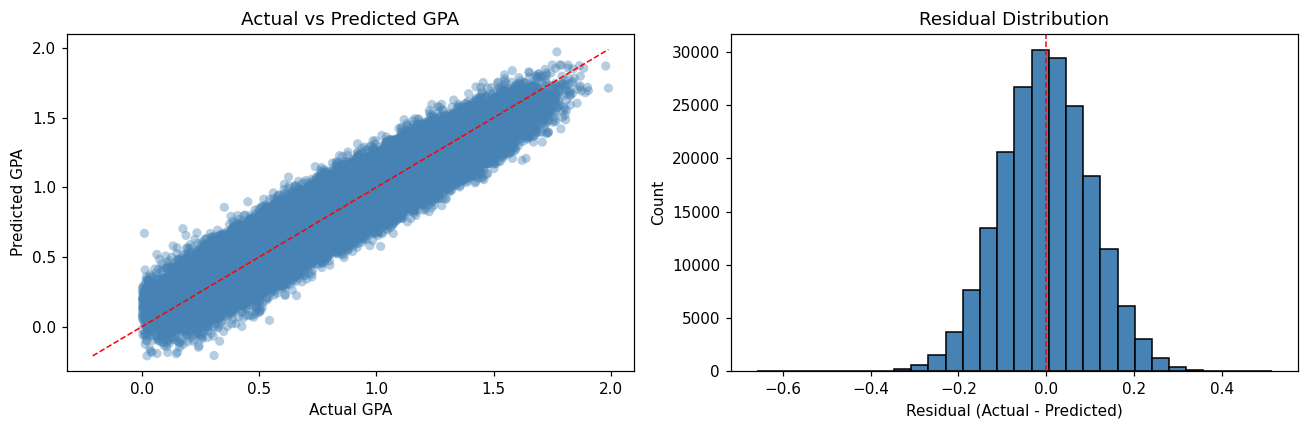

In [12]:
# Residual plots
predictions = trainer.predict(trainer.X_test)
residuals = trainer.y_test - predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs actual
axes[0].scatter(trainer.y_test, predictions, alpha=0.4, color="steelblue", edgecolors="none")
lims = [min(trainer.y_test.min(), predictions.min()),
        max(trainer.y_test.max(), predictions.max())]
axes[0].plot(lims, lims, "--", color="red", linewidth=1)
axes[0].set_xlabel("Actual GPA")
axes[0].set_ylabel("Predicted GPA")
axes[0].set_title("Actual vs Predicted GPA")

# Residual distribution
axes[1].hist(residuals, bins=30, edgecolor="black", color="steelblue")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

In [13]:
# enumerate() and zip() (Part 2 requirement)
coef_pairs = list(zip(FEATURE_COLUMNS, trainer.coef_))
coef_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

print("Top 5 most influential features (by |coefficient|):")
for rank, (feat, coef) in enumerate(coef_pairs[:5], start=1):
    direction = "up GPA" if coef > 0 else "down GPA"
    print(f"  {rank}. {feat:<35} coef = {coef:+.4f}  ({direction})")

Top 5 most influential features (by |coefficient|):
  1. previous_gpa                        coef = +0.1933  (up GPA)
  2. stress                              coef = -0.1121  (down GPA)
  3. motivation                          coef = +0.0951  (up GPA)
  4. phone_unlocks_per_day               coef = -0.0667  (down GPA)
  5. late_night_frequency                coef = +0.0612  (up GPA)


In [14]:
# map() (Part 2 requirement)
top3 = [feat for feat, _ in coef_pairs[:3]]
top3_upper = list(map(lambda c: c.upper(), top3))
print("Top 3 features (uppercased via map):", top3_upper)

Top 3 features (uppercased via map): ['PREVIOUS_GPA', 'STRESS', 'MOTIVATION']


In [15]:
# itertools built-in library (Part 2 requirement)
print("All pairs from top-3 features (itertools.combinations):")
for pair in itertools.combinations(top3, 2):
    print(" ", pair)

All pairs from top-3 features (itertools.combinations):
  ('previous_gpa', 'stress')
  ('previous_gpa', 'motivation')
  ('stress', 'motivation')


## 7. Predict GPA for a Custom Student

Edit the values below and re-run to get an instant GPA prediction.

In [16]:
# Dict (mutable) with number and string values (immutable)
student_profile: dict = {
    "stress"                : 5,
    "anxiety"               : 4,
    "depression"            : 3,
    "motivation"            : 7,
    "concentration"         : 7,
    "time_management"       : 7,
    "self_discipline"       : 8,
    "procrastination_score" : 3,
    "financial_stress"      : 4,
    "sleep_hours"           : 7,
    "late_night_frequency"  : 2,
    "phone_unlocks_per_day" : 50,
    "previous_gpa"          : 7.5,
}

# Exception-handling scenario 3: invalid input values
try:
    if not (0 <= student_profile["sleep_hours"] <= 24):
        raise ValueError("sleep_hours must be between 0 and 24.")
    if not (0 <= student_profile["previous_gpa"] <= 10):
        raise ValueError("previous_gpa must be between 0 and 10.")
except ValueError as e:
    print(f"[INPUT ERROR] {e}")
    raise

student_df = pd.DataFrame([student_profile])[FEATURE_COLUMNS]
predicted_gpa = trainer.predict(student_df).iloc[0]

print(f"Predicted GPA : {predicted_gpa:.3f}")
print(f"Dataset range : {y.min():.3f} - {y.max():.3f}")

Predicted GPA : 0.917
Dataset range : 0.000 - 2.009


## 8. Run Tests

In [17]:
import subprocess
result = subprocess.run(
    ["pytest", "-v", "test_data_pipeline.py", "test_model_trainer.py"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

============================= test session starts =============================
platform win32 -- Python 3.13.7, pytest-9.0.3, pluggy-1.6.0 -- C:\Python313\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\Matthew Feroz\Desktop\College\Spring 2026\Min Song - Python\Engineering-Programming-Python
plugins: anyio-4.12.1
collecting ... collected 7 items

test_data_pipeline.py::test_load_students_file PASSED                    [ 14%]
test_data_pipeline.py::test_clean_students_file PASSED                   [ 28%]
test_data_pipeline.py::test_missing_students_file PASSED                 [ 42%]
test_data_pipeline.py::test_get_features_and_target PASSED               [ 57%]
test_data_pipeline.py::test_get_features_and_target_missing_column PASSED [ 71%]
test_model_trainer.py::test_model_trainer_trains_and_predicts PASSED     [ 85%]
test_model_trainer.py::test_model_trainer_len_counts_training_rows PASSED [100%]

============================== 7 passed in 1.05s ==============================



## 9. `__name__` Guard Demo (Part 2)

All `.py` modules use `if __name__ == "__main__":` so they can be imported without side effects and also run standalone. The same pattern is demonstrated here:

In [18]:
if __name__ == "__main__":
    print("Running as main - mirrors the guard used in all .py modules.")

Running as main - mirrors the guard used in all .py modules.


## 10. Findings & Conclusions

**Result.** R² ≈ 0.880, MAE ≈ 0.08, RMSE ≈ 0.10 on the test set - the model is typically off by under a tenth of a GPA point.

**What matters (significant at p < 0.05).** `previous_gpa` dominates. On top of it, `stress` and `procrastination_score` and `phone_unlocks_per_day` push GPA down. `sleep_hours`, `motivation`, and `concentration` push it up. `anxiety`, `depression`, and `financial_stress` were not significant after controlling for the others.

**Limitations.**
- Self-reported features carry rater bias.
- Linear model misses interactions.
- Features are standardized (`StandardScaler`) before fitting so coefficients are on a comparable scale. `screen_time` was dropped from the modeling features because it is near-perfectly collinear with `late_night_frequency` in the source data (with both included, OLS produced ±85 cancelling coefficients that made predictions explode on inputs slightly off the training mean). After dropping it, all fitted coefficients are bounded and predictions on custom inputs stay inside the dataset's GPA range.
- `time_management` and `self_discipline` returned identical coefficients, indicating perfect collinearity (one could be dropped).
- Single 80/20 split on one dataset. `gpa` spans only ~0–2 and every row is labeled `Low`, so the model learns to rank within a narrow band rather than across the full GPA range.

**Takeaway.** Habit and well-being signals carry significant, directionally sensible predictive power on top of prior GPA - supporting the case for using them in early-warning systems rather than waiting for grades to slip.